In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
data=pd.read_csv('Cancer_Data.csv')

In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [77]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [78]:
data.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [79]:
data.drop('Unnamed: 32',axis=1,inplace=True)

In [80]:
data.dropna(inplace=True)

In [81]:
data.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [82]:
data.drop_duplicates(inplace=True)

In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [84]:
q1=data['area_mean'].quantile(0.25)
q3=data['area_mean'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
data=data[(data['area_mean']>=lower_bound) & (data['area_mean']<=upper_bound)]

In [85]:
x=data.drop('diagnosis',axis=1)
y=data['diagnosis']

In [86]:
quant=[]
cat=[]
for i in x.columns:
    if x[i].nunique()>15:
        quant.append(i)
    else:
        cat.append(i)

In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 544 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       544 non-null    int64  
 1   diagnosis                544 non-null    object 
 2   radius_mean              544 non-null    float64
 3   texture_mean             544 non-null    float64
 4   perimeter_mean           544 non-null    float64
 5   area_mean                544 non-null    float64
 6   smoothness_mean          544 non-null    float64
 7   compactness_mean         544 non-null    float64
 8   concavity_mean           544 non-null    float64
 9   concave points_mean      544 non-null    float64
 10  symmetry_mean            544 non-null    float64
 11  fractal_dimension_mean   544 non-null    float64
 12  radius_se                544 non-null    float64
 13  texture_se               544 non-null    float64
 14  perimeter_se             544 no

In [88]:
from sklearn.preprocessing import StandardScaler
for i in quant:
    ss= StandardScaler()
    x[i]=ss.fit_transform(x[[i]])

In [89]:
x.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,-0.232673,1.431985,-2.049264,1.643846,1.437201,1.609820,3.506035,3.092072,3.047488,2.244848,...,2.369714,-1.338944,2.878823,2.769892,1.311223,2.678113,2.227969,2.529901,2.733861,1.909210
1,-0.232671,2.296479,-0.325132,2.136775,2.626377,-0.802250,-0.447262,0.077827,0.755891,0.018641,...,2.274195,-0.346475,1.965281,2.626143,-0.355442,-0.397224,-0.092941,1.243186,-0.242725,0.274857
2,0.487919,2.001613,0.486774,1.995241,2.176319,0.979213,1.167358,1.640088,2.475557,0.961203,...,1.926408,-0.000417,1.742206,2.062556,0.538654,1.130172,0.937478,2.166898,1.145062,0.196093
3,0.488328,-0.769459,0.283797,-0.563109,-0.812719,3.336821,3.631215,2.262165,1.799367,2.897672,...,-0.194603,0.157921,-0.156758,-0.541579,3.377194,3.966673,2.104596,2.401878,6.009554,4.868332
4,0.488415,2.202658,-1.125372,2.244145,2.520265,0.312777,0.628887,1.648571,1.772558,0.007638,...,1.674140,-1.446679,1.731584,1.756805,0.234835,-0.279090,0.688756,0.862357,-0.863450,-0.394638


In [90]:
data=x.copy()
data['diagnosis']=y

<Axes: >

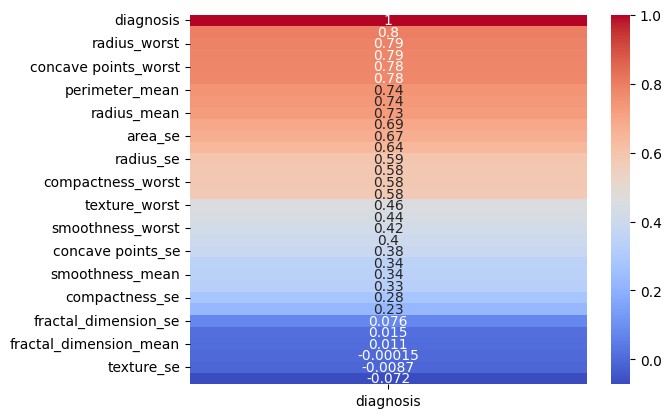

In [91]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['diagnosis']=le.fit_transform(data['diagnosis'])

corr=data.corr()

labeled_corr=corr[['diagnosis']].sort_values(by='diagnosis',ascending=False)

sns.heatmap(labeled_corr,annot=True,cmap='coolwarm')


In [92]:
data=data.drop('fractal_dimension_mean',axis=1)

In [93]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 544 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       544 non-null    float64
 1   radius_mean              544 non-null    float64
 2   texture_mean             544 non-null    float64
 3   perimeter_mean           544 non-null    float64
 4   area_mean                544 non-null    float64
 5   smoothness_mean          544 non-null    float64
 6   compactness_mean         544 non-null    float64
 7   concavity_mean           544 non-null    float64
 8   concave points_mean      544 non-null    float64
 9   symmetry_mean            544 non-null    float64
 10  radius_se                544 non-null    float64
 11  texture_se               544 non-null    float64
 12  perimeter_se             544 non-null    float64
 13  area_se                  544 non-null    float64
 14  smoothness_se            544 no

In [94]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

# **Voting**

In [95]:
# soft_voting
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

dt=DecisionTreeClassifier(criterion="entropy",max_depth=3)
lr=LogisticRegression()
svc=SVC(probability=True)
vc=VotingClassifier(estimators=[('dt',dt),('lr',lr),('svc',svc)],voting='soft')

for model in (dt,lr,svc,vc):
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)

print(f"classification_report \n \n {classification_report(y_test,y_pred)}")

classification_report 
 
               precision    recall  f1-score   support

           B       0.96      0.99      0.98       100
           M       0.98      0.94      0.96        64

    accuracy                           0.97       164
   macro avg       0.97      0.96      0.97       164
weighted avg       0.97      0.97      0.97       164



In [96]:
#hard_voting
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

dt=DecisionTreeClassifier(criterion="entropy",max_depth=3)
lr=LogisticRegression()
svc=SVC()
vc=VotingClassifier(estimators=[('dtc',dt),('lr',lr),('svc',svc)],voting='hard')

for model in (dt,lr,svc,vc):
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)

print(f"classification_report \n \n {classification_report(y_test,y_pred)}")

classification_report 
 
               precision    recall  f1-score   support

           B       0.97      1.00      0.99       100
           M       1.00      0.95      0.98        64

    accuracy                           0.98       164
   macro avg       0.99      0.98      0.98       164
weighted avg       0.98      0.98      0.98       164



# **Bagging & Pasting**



In [97]:
#Bagging
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
lr=LogisticRegression(max_iter=200)
bg=BaggingClassifier(estimator=lr,n_estimators=30,max_samples=280,bootstrap=True)
bg.fit(x_train,y_train)
y_pred=bg.predict(x_test)
print(f"Classification_Report \n \n{classification_report(y_test,y_pred)}")


Classification_Report 
 
              precision    recall  f1-score   support

           B       0.95      1.00      0.98       100
           M       1.00      0.92      0.96        64

    accuracy                           0.97       164
   macro avg       0.98      0.96      0.97       164
weighted avg       0.97      0.97      0.97       164



In [98]:
#Pasting
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=200)
bg=BaggingClassifier(estimator=lr,n_estimators=30,max_samples=280,bootstrap=False)
bg.fit(x_train,y_train)
y_pred=bg.predict(x_test)
print(f"Classification_Report \n \n{classification_report(y_test,y_pred)}")

Classification_Report 
 
              precision    recall  f1-score   support

           B       0.96      1.00      0.98       100
           M       1.00      0.94      0.97        64

    accuracy                           0.98       164
   macro avg       0.98      0.97      0.97       164
weighted avg       0.98      0.98      0.98       164



In [99]:
#Random_forest
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=20,criterion='entropy',max_depth=3)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
print(f"Classification_Report \n \n{classification_report(y_test,y_pred)}")

Classification_Report 
 
              precision    recall  f1-score   support

           B       0.93      0.99      0.96       100
           M       0.98      0.88      0.93        64

    accuracy                           0.95       164
   macro avg       0.95      0.93      0.94       164
weighted avg       0.95      0.95      0.94       164



# **Boosting**


In [110]:
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
ada=AdaBoostClassifier(n_estimators=100)
ada.fit(x_train,y_train)
y_pred=ada.predict(x_test)
print(f"Ada_boost \n \n{classification_report(y_test,y_pred)}")

gradient=GradientBoostingClassifier(n_estimators=100)
gradient.fit(x_train,y_train)
y_pred=gradient.predict(x_test)
print(f"Gradient_boost \n \n{classification_report(y_test,y_pred)}")

# #label encoder
# from sklearn.preprocessing import LabelEncoder
# le=LabelEncoder()
# y_train=le.fit_transform(y_train)
# y_test=le.transform(y_test)

xgb=XGBClassifier(n_estimators=100,use_label_encoder=True,eval_metric="logloss")
xgb.fit(x_train,y_train)
y_pred=xgb.predict(x_test)
print(f"XGBoost \n \n{classification_report(y_test,y_pred)}")

Ada_boost 
 
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       100
           1       0.98      0.89      0.93        64

    accuracy                           0.95       164
   macro avg       0.96      0.94      0.95       164
weighted avg       0.95      0.95      0.95       164

Gradient_boost 
 
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       100
           1       0.95      0.91      0.93        64

    accuracy                           0.95       164
   macro avg       0.95      0.94      0.94       164
weighted avg       0.95      0.95      0.94       164

XGBoost 
 
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       100
           1       0.97      0.92      0.94        64

    accuracy                           0.96       164
   macro avg       0.96      0.95      0.95       164
weighted avg       0.96      0.9

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:58:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
